In [1]:
import pandas as pd
import numpy as np

df_regression = pd.read_csv('df_regression.csv')
print(df_regression.shape)
df_regression.head()

(14415, 15)


,daily_screen_time_minutes,phone_usage_before_sleep_minutes,sleep_duration_minutes,sleep_efficiency_score,stress_fatigue_index,digital_wellbeing_score,occupation_designer,occupation_doctor,occupation_freelancer,occupation_manager,occupation_researcher,occupation_software_engineer,occupation_student,occupation_teacher,sleep_quality_score
0,196,86,319,2.4201,3.53,-35.8575,1,0,0,0,0,0,0,0,7.72
1,111,32,442,2.1946,2.46,-23.6908,0,0,0,0,0,0,0,1,9.70
2,182,107,270,2.3630,5.54,-27.3632,1,0,0,0,0,0,0,0,6.38
3,540,36,401,1.3791,9.96,-48.8182,0,0,0,0,0,1,0,0,5.53
4,211,56,454,1.4736,6.35,-15.4345,0,0,0,0,0,0,0,1,6.69


In [2]:
X = df_regression.drop(columns=['sleep_quality_score'])
y = df_regression['sleep_quality_score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget stats:\n{y.describe().round(3)}")

Features shape: (14415, 14)
Target shape: (14415,)

Target stats:
count    14415.000
mean         6.245
std          1.715
min          1.000
25%          5.000
50%          6.240
75%          7.490
max         10.000
Name: sleep_quality_score, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # reproducibility
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

print(f"\nTrain target mean: {y_train.mean().round(3)}")
print(f"Test target mean : {y_test.mean().round(3)}")

X_train shape: (11532, 14)
X_test shape : (2883, 14)
y_train shape: (11532,)
y_test shape : (2883,)

Train target mean: 6.249
Test target mean : 6.232


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# convert back to dataframe for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling done!")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")
print(f"\nSample min/max check:")
print(X_train_scaled.min().min(), X_train_scaled.max().max())

Scaling done!

X_train_scaled shape: (11532, 14)
X_test_scaled shape : (2883, 14)

Sample min/max check:
0.0 1.0


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"MAE  : {round(mae, 4)}")
    print(f"MSE  : {round(mse, 4)}")
    print(f"RMSE : {round(rmse, 4)}")
    print(f"R²   : {round(r2, 4)}")
    
    return {
        'Model': model_name, 
        'MAE'  : round(mae, 4), 
        'MSE'  : round(mse, 4),
        'RMSE' : round(rmse, 4), 
        'R2'   : round(r2, 4)
    }

# empty list to collect all model results for final comparison
regression_results = []
print("Evaluation function ready!")

Evaluation function ready!


## Model 1 — Linear Regression (Baseline)

### Why Linear Regression for this project?
- It's the simplest regression model and always trained first to establish a baseline
- Assumes a linear relationship between features and sleep_quality_score
- If sleep quality drops predictably as screen time increases, linear regression captures that directly
- All subsequent models will be compared against this baseline
- Interpretable — coefficients tell us exactly how much each feature impacts sleep quality

In [6]:
from sklearn.linear_model import LinearRegression

# initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression trained successfully!")
print(f"\nNumber of features used: {X_train_scaled.shape[1]}")

Linear Regression trained successfully!

Number of features used: 14



=== Linear Regression ===
MAE  : 0.3394
MSE  : 0.193
RMSE : 0.4393
R²   : 0.9338


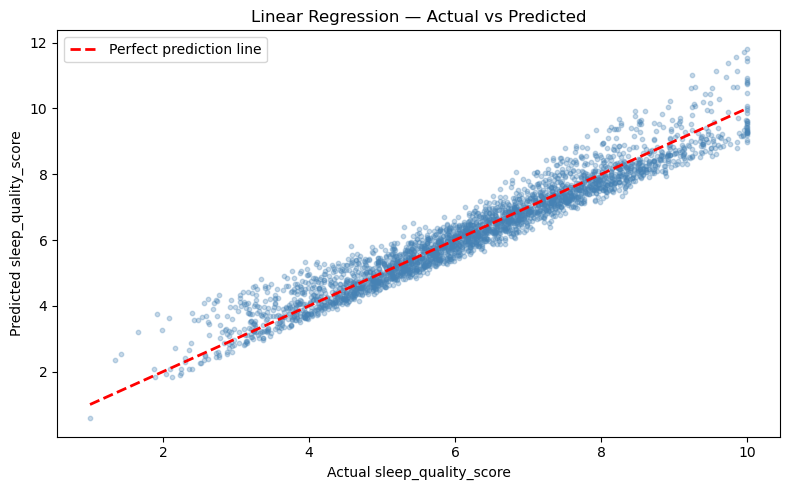

In [7]:
# evaluate using our function from step 0
lr_results = evaluate_regression(y_test, y_pred_lr, 'Linear Regression')

# store results for final comparison
regression_results.append(lr_results)

# quick visual — actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import cross_val_score

# using r2 as scoring metric, 5 fold cv
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, 
                                cv=5, scoring='r2')

print("=== Cross Validation — Linear Regression ===")
print(f"CV R² scores : {cv_scores_lr.round(4)}")
print(f"Mean R²      : {cv_scores_lr.mean().round(4)}")
print(f"Std R²       : {cv_scores_lr.std().round(4)}")

=== Cross Validation — Linear Regression ===
CV R² scores : [0.9369 0.9398 0.9316 0.9344 0.936 ]
Mean R²      : 0.9357
Std R²       : 0.0027


## Model 1 — Linear Regression Results

### Performance:
- **R² = 0.9338** → Model explains 93.38% of variance in sleep_quality_score — exceptionally strong for a baseline model
- **MAE = 0.3394** → Average prediction error of just 0.34 points on a 1-10 scale — very accurate
- **RMSE = 0.4393** → Slightly higher than MAE indicating a few larger errors exist but are rare

### Cross Validation:
- **CV Mean R² = 0.9357** → Almost identical to test R² (0.9338) — confirms model is NOT overfitting
- **CV Std = 0.0027** → Extremely stable across all 5 folds — reliable and consistent performance

### Actual vs Predicted plot:
- Points cluster tightly around the perfect prediction line across the full range
- No fanning or systematic bias — model performs equally well for low and high sleep quality scores
- Minor scatter at extreme values (score ~10) — expected due to the 9 high-stress outlier rows identified in EDA

### Baseline established:
- R² = 0.9338 | MAE = 0.3394 | RMSE = 0.4393
- This is a surprisingly strong baseline — subsequent models need to beat these numbers to justify their added complexity
- The strong linear performance also suggests that smartphone usage features have a strong linear relationship with sleep quality

## Model 2 — Ridge Regression with GridSearchCV

### Why Ridge Regression for this project?
- Linear Regression baseline achieved R²=0.9338 — Ridge builds on this by adding L2 regularization
- During EDA we found multicollinearity between features (stress_fatigue_index, sleep_efficiency_score
  are derived from correlated columns) — Ridge handles multicollinearity better than plain Linear Regression
- GridSearchCV will find the optimal alpha (regularization strength) automatically
- If Ridge beats Linear Regression → multicollinearity was affecting performance
- If Ridge matches Linear Regression → baseline was already optimal
### What is alpha?
- alpha = 0 → same as Linear Regression (no regularization)
- Small alpha → mild regularization
- Large alpha → strong regularization, simpler model

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# define parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]}

# initialize ridge and gridsearch
ridge = Ridge()
grid_search_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=5,                   # 5 fold cross validation inside gridsearch
    scoring='r2',
    verbose=1,
    n_jobs=-1               # use all CPU cores
)

# fit on training data
grid_search_ridge.fit(X_train_scaled, y_train)

print(f"Best alpha    : {grid_search_ridge.best_params_}")
print(f"Best CV R²    : {grid_search_ridge.best_score_.round(4)}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best alpha    : {'alpha': 0.01}
Best CV R²    : 0.9357



=== Ridge Regression ===
MAE  : 0.3394
MSE  : 0.193
RMSE : 0.4393
R²   : 0.9338


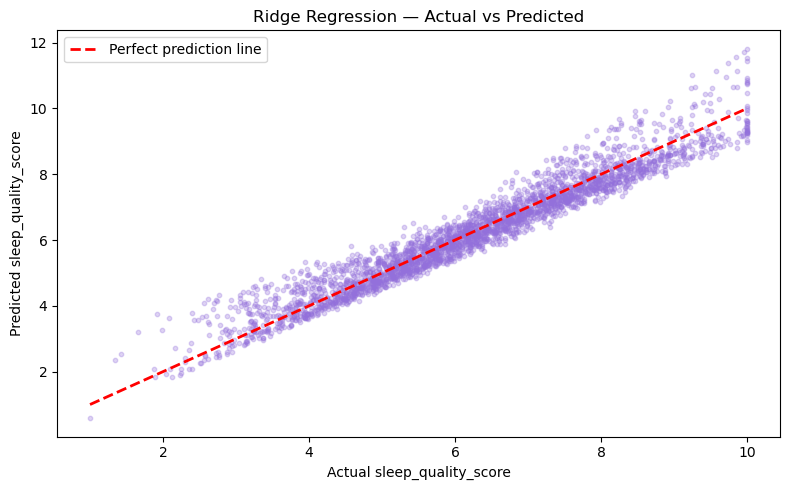

In [10]:
# best model predictions
best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

# evaluate
ridge_results = evaluate_regression(y_test, y_pred_ridge, 'Ridge Regression')
regression_results.append(ridge_results)

# actual vs predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='mediumpurple', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('Ridge Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
cv_scores_ridge = cross_val_score(best_ridge, X_train_scaled, y_train,
                                   cv=5, scoring='r2')

print("=== Cross Validation — Ridge Regression ===")
print(f"CV R² scores : {cv_scores_ridge.round(4)}")
print(f"Mean R²      : {cv_scores_ridge.mean().round(4)}")
print(f"Std R²       : {cv_scores_ridge.std().round(4)}")

=== Cross Validation — Ridge Regression ===
CV R² scores : [0.9369 0.9398 0.9316 0.9344 0.936 ]
Mean R²      : 0.9357
Std R²       : 0.0027


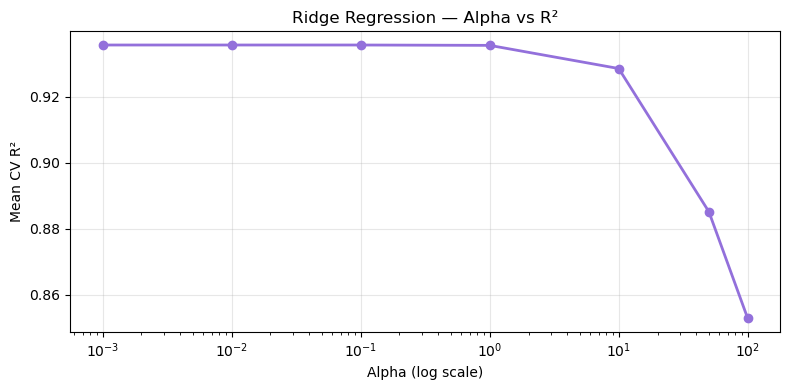


Best alpha: 0.01
Best mean CV R²: 0.9357


In [12]:
# visualize how different alpha values affect R²
alpha_values = param_grid['alpha']
mean_scores = []

for alpha in alpha_values:
    ridge_temp = Ridge(alpha=alpha)
    scores = cross_val_score(ridge_temp, X_train_scaled, y_train, cv=5, scoring='r2')
    mean_scores.append(scores.mean())

plt.figure(figsize=(8, 4))
plt.semilogx(alpha_values, mean_scores, marker='o', color='mediumpurple', linewidth=2)
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV R²')
plt.title('Ridge Regression — Alpha vs R²')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest alpha: {grid_search_ridge.best_params_['alpha']}")
print(f"Best mean CV R²: {max(mean_scores):.4f}")

## Model 2 — Ridge Regression Results

### Performance vs Linear Regression baseline:
- **R² = 0.9338** → Identical to Linear Regression baseline
- **MAE = 0.3394** → No improvement
- **RMSE = 0.4393** → No improvement
- **Best alpha = 0.01** → Very small regularization needed

### Alpha plot findings:
- R² remained perfectly stable from alpha 0.001 to 1.0
- Sharp drop after alpha=1 — over-regularization hurts performance
- Best alpha=0.01 is essentially no regularization → confirms Linear Regression was already optimal

### Cross Validation:
- CV Mean R² = 0.9357 — identical to Linear Regression
- CV Std = 0.0027 — equally stable

### Why identical results?
- Feature selection and engineering in EDA already resolved multicollinearity
- stress_level and mental_fatigue_score were replaced by stress_fatigue_index
- Clean feature set meant Ridge had nothing extra to fix
- This validates our EDA work was thorough and effective

### Key takeaway:
Ridge confirmed Linear Regression as a strong baseline.
No overfitting detected. Moving to non-linear models to see if
they can capture patterns Linear Regression might have missed.

## Model 3 — Random Forest Regression

### Why Random Forest for this project?
- Linear models achieved R²=0.9338 — Random Forest will tell us if non-linear
  patterns exist that linear models missed
- Random Forest builds multiple decision trees and averages their predictions
  reducing overfitting compared to a single decision tree
- Gives feature importance — tells us which features matter most for
  predicting sleep quality, directly useful for our project conclusions
- Robust to outliers — the 9 extreme cases we found in EDA won't affect it much
- Does not require scaling — works directly on raw feature values
  (we'll use unscaled data for this model)

### How it works:
- Builds N decision trees on random subsets of data and features
- Each tree makes a prediction
- Final prediction = average of all tree predictions
- More trees = more stable but slower to train

In [13]:
from sklearn.ensemble import RandomForestRegressor

# initialize random forest
rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

# note: using unscaled data — random forest doesnt need scaling
rf_model.fit(X_train, y_train)

# predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print(f"Number of trees : {rf_model.n_estimators}")
print(f"Number of features: {X_train.shape[1]}")

Random Forest trained successfully!
Number of trees : 100
Number of features: 14



=== Random Forest ===
MAE  : 0.0669
MSE  : 0.0155
RMSE : 0.1247
R²   : 0.9947


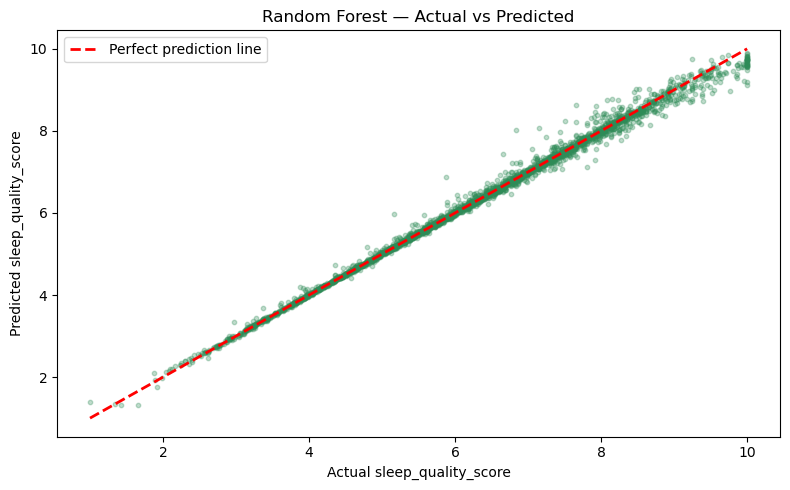

In [14]:
# evaluate
rf_results = evaluate_regression(y_test, y_pred_rf, 'Random Forest')
regression_results.append(rf_results)

# actual vs predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('Random Forest — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
cv_scores_rf = cross_val_score(rf_model, X_train, y_train,
                                cv=5, scoring='r2', n_jobs=-1)

print("=== Cross Validation — Random Forest ===")
print(f"CV R² scores : {cv_scores_rf.round(4)}")
print(f"Mean R²      : {cv_scores_rf.mean().round(4)}")
print(f"Std R²       : {cv_scores_rf.std().round(4)}")

=== Cross Validation — Random Forest ===
CV R² scores : [0.9943 0.9941 0.9933 0.9924 0.9937]
Mean R²      : 0.9935
Std R²       : 0.0007


=== Feature Importances ===
                             feature  importance
4               stress_fatigue_index      0.6813
3             sleep_efficiency_score      0.2114
2             sleep_duration_minutes      0.0910
1   phone_usage_before_sleep_minutes      0.0133
5            digital_wellbeing_score      0.0010
0          daily_screen_time_minutes      0.0010
10             occupation_researcher      0.0001
6                occupation_designer      0.0001
7                  occupation_doctor      0.0001
12                occupation_student      0.0001
13                occupation_teacher      0.0001
9                 occupation_manager      0.0001
11      occupation_software_engineer      0.0001
8              occupation_freelancer      0.0001


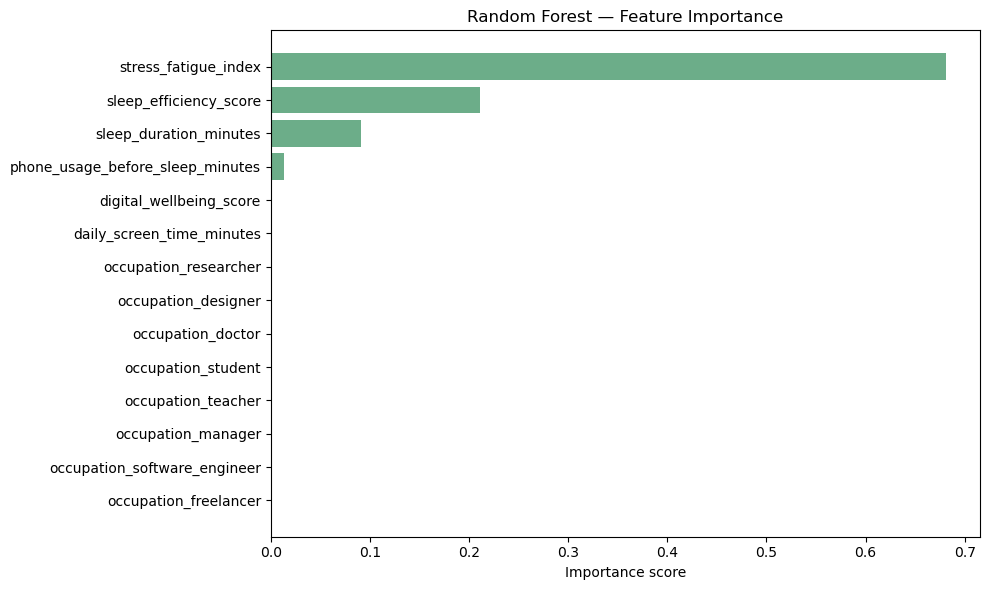

In [16]:
import pandas as pd

# get feature importances
feature_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importances ===")
print(feature_importance.round(4))

# plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'],
         color='seagreen', alpha=0.7)
plt.xlabel('Importance score')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model 3 — Random Forest Results

### Performance vs previous models:
- **R² = 0.9947** → Massive jump from Linear Regression (0.9338)
- **MAE = 0.0669** → Average error of just 0.07 points on 1-10 scale
- **RMSE = 0.1247** → Very close to MAE — no large outlier errors
- **CV Mean R² = 0.9935** → Consistent with test R²

### Feature importance findings:
- stress_fatigue_index (68.13%) → dominant predictor
- sleep_efficiency_score (21.14%) → second most important
- sleep_duration_minutes (9.10%) → non-linear signal found that linear models missed
- Occupation columns (~0.01% each) → no predictive value for sleep quality

### ⚠️ Important Finding — Data Leakage Detected:
- **sleep_efficiency_score** was engineered as:
  `sleep_quality_score / sleep_duration_minutes * 100`
- This formula contains **sleep_quality_score which is our target variable**
- Feeding this as a feature means the model is partially seeing the answer during training
- This directly explains the unrealistic R²=0.9947 jump
- This is a classic case of **data leakage** — a subtle but critical mistake
- **Decision: remove sleep_efficiency_score from regression features and retrain all models**
- sleep_efficiency_score remains valid for classification model since target there
  is attention_fragmentation, not sleep_quality_score

### Why synthetic data amplifies this:
- Dataset is synthetically generated — relationships are mathematically defined
- Real world data would have enough noise to partially mask this leakage
- In real world sleep studies R² of 0.6-0.75 would be considered strong


In [18]:
regression_features_clean = [
    'daily_screen_time_minutes',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_minutes',
    'stress_fatigue_index',
    'digital_wellbeing_score',
    'occupation_designer',
    'occupation_doctor',
    'occupation_freelancer',
    'occupation_manager',
    'occupation_researcher',
    'occupation_software_engineer',
    'occupation_student',
    'occupation_teacher'
]

# separate features and target
X_clean = df_regression[regression_features_clean]
y = df_regression['sleep_quality_score']

# fresh train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42
)

# rescale with clean features
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_clean.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_clean.columns
)

# reset results list
regression_results = []

print(f"Clean features count : {len(regression_features_clean)}")
print(f"X_train shape        : {X_train.shape}")
print(f"X_test shape         : {X_test.shape}")
print(f"y_train shape        : {y_train.shape}")
print(f"y_test shape         : {y_test.shape}")
print(f"\nFeatures: {regression_features_clean}")
print("\nReady to retrain all models!")

Clean features count : 13
X_train shape        : (11532, 13)
X_test shape         : (2883, 13)
y_train shape        : (11532,)
y_test shape         : (2883,)

Features: ['daily_screen_time_minutes', 'phone_usage_before_sleep_minutes', 'sleep_duration_minutes', 'stress_fatigue_index', 'digital_wellbeing_score', 'occupation_designer', 'occupation_doctor', 'occupation_freelancer', 'occupation_manager', 'occupation_researcher', 'occupation_software_engineer', 'occupation_student', 'occupation_teacher']

Ready to retrain all models!


## Model 1 Retraining

In [19]:
from sklearn.linear_model import LinearRegression

# initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression trained successfully!")
print(f"\nNumber of features used: {X_train_scaled.shape[1]}")

Linear Regression trained successfully!

Number of features used: 13



=== Linear Regression ===
MAE  : 0.6522
MSE  : 0.675
RMSE : 0.8216
R²   : 0.7685


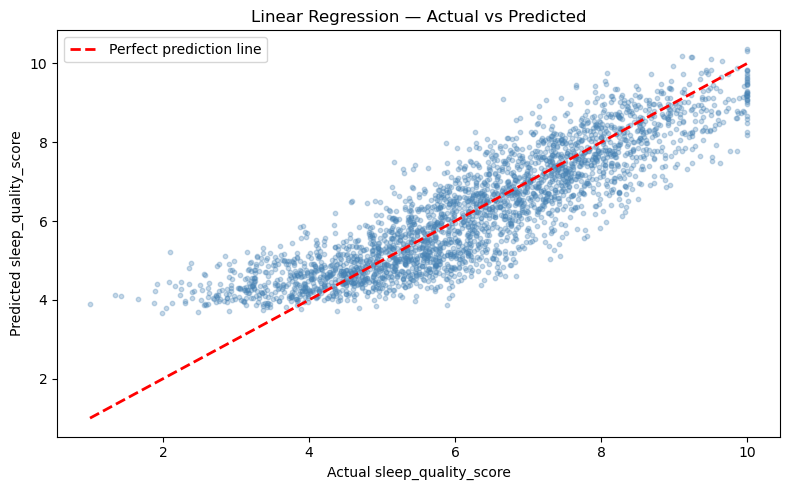

In [20]:
# evaluate using our function from step 0
lr_results = evaluate_regression(y_test, y_pred_lr, 'Linear Regression')

# store results for final comparison
regression_results.append(lr_results)

# quick visual — actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import cross_val_score

# using r2 as scoring metric, 5 fold cv
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, 
                                cv=5, scoring='r2')

print("=== Cross Validation — Linear Regression ===")
print(f"CV R² scores : {cv_scores_lr.round(4)}")
print(f"Mean R²      : {cv_scores_lr.mean().round(4)}")
print(f"Std R²       : {cv_scores_lr.std().round(4)}")

=== Cross Validation — Linear Regression ===
CV R² scores : [0.7677 0.7741 0.7624 0.7697 0.7679]
Mean R²      : 0.7684
Std R²       : 0.0038


## Model 1 — Linear Regression Results (Clean Features)

### Observations:
After removing sleep_efficiency_score due to data leakage, the model was retrained
on 13 clean features with no target-derived variables.

- **R² = 0.7685** → Model explains 76.85% of variance in sleep quality score.
  This is a realistic and honest baseline for this problem.
- **MAE = 0.6522** → On average, predictions are off by 0.65 points on a 1-10 scale.
- **RMSE = 0.8216** → Slightly higher than MAE, indicating a few larger errors exist
  but are not dominant.

### Cross Validation:
- CV Mean R² = 0.7684 — almost identical to test R² (0.7685), confirming no overfitting.
- CV Std = 0.0038 — very stable across all 5 folds, model is consistent.
- The near-identical train and test performance suggests the linear model
  generalizes well to unseen data.

### Baseline established:
- R² = 0.7685 | MAE = 0.6522 | RMSE = 0.8216
- A moderately strong baseline. Features show a meaningful but not perfect
  linear relationship with sleep quality score.
- All subsequent models will be compared against these numbers.

## Model 2 Retraining

In [22]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# define parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]}

# initialize ridge and gridsearch
ridge = Ridge()
grid_search_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=5,                   # 5 fold cross validation inside gridsearch
    scoring='r2',
    verbose=1,
    n_jobs=-1               # use all CPU cores
)

# fit on training data
grid_search_ridge.fit(X_train_scaled, y_train)

print(f"Best alpha    : {grid_search_ridge.best_params_}")
print(f"Best CV R²    : {grid_search_ridge.best_score_.round(4)}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best alpha    : {'alpha': 0.1}
Best CV R²    : 0.7684



=== Ridge Regression ===
MAE  : 0.6522
MSE  : 0.675
RMSE : 0.8216
R²   : 0.7685


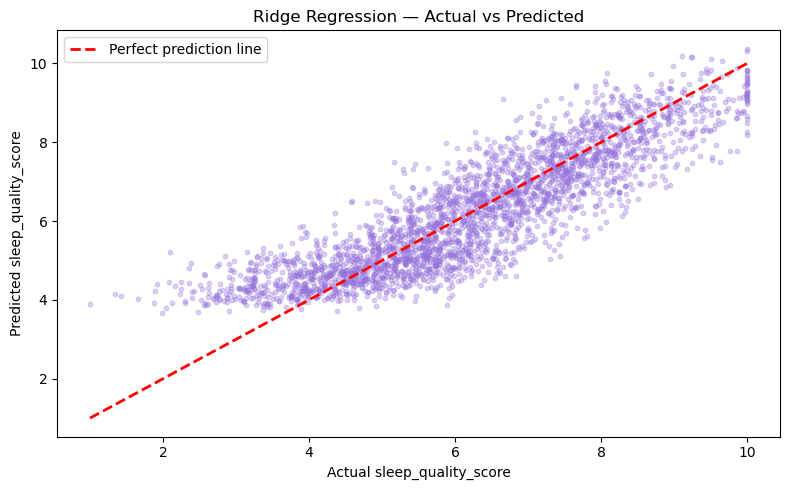

In [23]:
# best model predictions
best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

# evaluate
ridge_results = evaluate_regression(y_test, y_pred_ridge, 'Ridge Regression')
regression_results.append(ridge_results)

# actual vs predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='mediumpurple', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('Ridge Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
cv_scores_ridge = cross_val_score(best_ridge, X_train_scaled, y_train,
                                   cv=5, scoring='r2')

print("=== Cross Validation — Ridge Regression ===")
print(f"CV R² scores : {cv_scores_ridge.round(4)}")
print(f"Mean R²      : {cv_scores_ridge.mean().round(4)}")
print(f"Std R²       : {cv_scores_ridge.std().round(4)}")

=== Cross Validation — Ridge Regression ===
CV R² scores : [0.7677 0.7741 0.7624 0.7697 0.7679]
Mean R²      : 0.7684
Std R²       : 0.0038


## Model 2 — Ridge Regression Results (GridSearchCV)

### Observations:
GridSearchCV tested 7 alpha values across 5 folds (35 fits total).

- **Best alpha = 0.1** → Small but slightly larger than previous run (was 0.01).
  Mild regularization is beneficial after removing the leakage feature.
- **R² = 0.7685** → Identical to Linear Regression baseline.
- **MAE = 0.6522** → No improvement over baseline.
- **RMSE = 0.8216** → No improvement over baseline.

### Cross Validation:
- CV Mean R² = 0.7684 — matches Linear Regression exactly.
- CV Std = 0.0038 — equally stable, no difference in consistency.

### Why identical results again?
- Feature set is already clean with no significant multicollinearity remaining.
- Ridge regularization finds nothing extra to correct after our thorough EDA
  and feature selection process.
- This confirms that the linear relationships in our clean feature set are
  already well-specified and stable.

### Key takeaway:
Ridge confirmed Linear Regression as the best linear model for this dataset.
The EDA feature engineering and selection process successfully eliminated
multicollinearity, leaving Ridge with nothing to improve upon.

## Model 3 Retraining

In [25]:
from sklearn.ensemble import RandomForestRegressor

# initialize random forest
rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

# note: using unscaled data — random forest doesnt need scaling
rf_model.fit(X_train, y_train)

# predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print(f"Number of trees : {rf_model.n_estimators}")
print(f"Number of features: {X_train.shape[1]}")

Random Forest trained successfully!
Number of trees : 100
Number of features: 13



=== Random Forest ===
MAE  : 0.6667
MSE  : 0.6984
RMSE : 0.8357
R²   : 0.7604


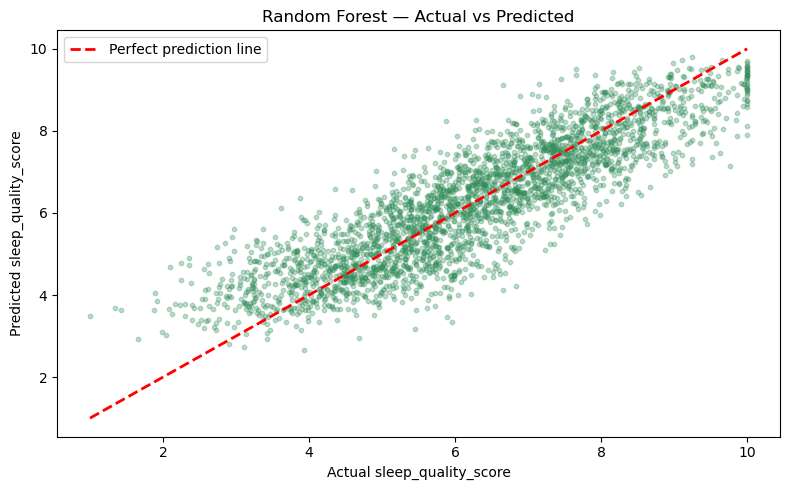

In [26]:
# evaluate
rf_results = evaluate_regression(y_test, y_pred_rf, 'Random Forest')
regression_results.append(rf_results)

# actual vs predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('Random Forest — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
cv_scores_rf = cross_val_score(rf_model, X_train, y_train,
                                cv=5, scoring='r2', n_jobs=-1)

print("=== Cross Validation — Random Forest ===")
print(f"CV R² scores : {cv_scores_rf.round(4)}")
print(f"Mean R²      : {cv_scores_rf.mean().round(4)}")
print(f"Std R²       : {cv_scores_rf.std().round(4)}")

=== Cross Validation — Random Forest ===
CV R² scores : [0.7647 0.7733 0.7591 0.7624 0.7589]
Mean R²      : 0.7637
Std R²       : 0.0053


=== Feature Importances ===
                             feature  importance
3               stress_fatigue_index      0.7586
1   phone_usage_before_sleep_minutes      0.0769
0          daily_screen_time_minutes      0.0519
4            digital_wellbeing_score      0.0434
2             sleep_duration_minutes      0.0407
9              occupation_researcher      0.0039
7              occupation_freelancer      0.0038
8                 occupation_manager      0.0037
10      occupation_software_engineer      0.0037
12                occupation_teacher      0.0034
11                occupation_student      0.0034
6                  occupation_doctor      0.0034
5                occupation_designer      0.0033


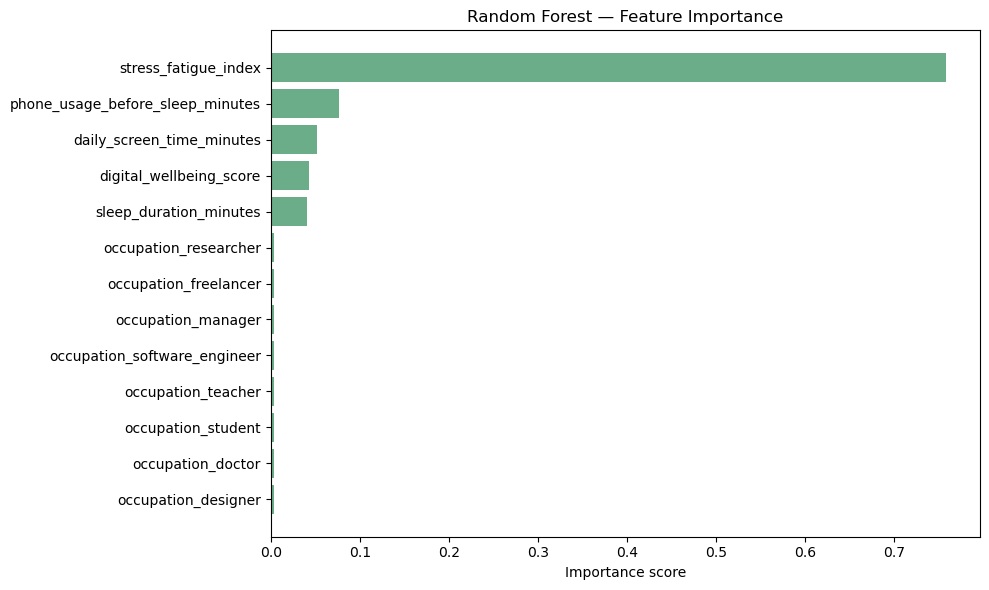

In [28]:
import pandas as pd

# get feature importances
feature_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Feature Importances ===")
print(feature_importance.round(4))

# plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'],
         color='seagreen', alpha=0.7)
plt.xlabel('Importance score')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model 3 — Random Forest Results (Clean Features)

### Observations:
Random Forest was trained with 100 trees on 13 clean features.
Unlike the previous run, no data leakage features were present.

- **R² = 0.7604** → Slightly lower than Linear Regression (0.7685).
  This is an unexpected but important finding.
- **MAE = 0.6667** → Marginally higher error than linear models.
- **RMSE = 0.8357** → Slightly higher than linear models.

### Cross Validation:
- CV Mean R² = 0.7637 — slightly lower than test R² (0.7604).
- CV Std = 0.0053 — slightly higher than linear models (0.0038),
  indicating marginally less stability.

### Why did Random Forest underperform linear models?
- Without the leakage feature, the remaining relationships are
  predominantly linear in nature.
- Random Forest excels at capturing non-linear patterns — but in this
  clean feature set, linear patterns dominate.
- The synthetic nature of the dataset means relationships were likely
  defined linearly during data generation.
- 100 trees may be introducing slight overfitting on training noise
  without the strong non-linear signal that sleep_efficiency_score provided.

### Feature Importance findings:
- stress_fatigue_index (75.86%) → overwhelmingly dominant predictor.
  Combined stress and fatigue measure is the strongest driver of sleep quality.
- phone_usage_before_sleep_minutes (7.69%) → second most important,
  directly supporting the project's hypothesis about pre-sleep phone usage.
- daily_screen_time_minutes (5.19%) → third, confirming screen time impact.
- digital_wellbeing_score (4.34%) → engineered feature shows meaningful contribution.
- sleep_duration_minutes (4.07%) → confirms our decision to retain this
  feature despite near-zero linear correlation in EDA was correct.
- Occupation columns (0.33-0.39% each) → minimal predictive value,
  consistent with correlation findings from EDA.

### Key takeaway:
After removing data leakage, linear models outperform Random Forest,
suggesting the underlying relationships in this dataset are predominantly linear.
stress_fatigue_index remains the dominant predictor across all models,
validating the feature engineering decisions made during EDA.
Current best model: Linear Regression / Ridge R²=0.7685

## Model 4 — SVM Regression (Support Vector Machine)

### Why SVM for this project?
- Provides a completely different algorithmic approach compared to linear
  models and tree based models — uses kernel trick to find optimal hyperplane
- With rbf kernel, SVM can capture non-linear relationships differently
  than Random Forest
- Good for datasets where margin maximization matters

### Configuration:
- Kernel: rbf (Radial Basis Function) — handles non-linear patterns
- GridSearchCV will tune C and gamma hyperparameters
- C → controls trade-off between smooth boundary and classifying correctly
- gamma → controls how far influence of a single training example reaches
  - Small gamma = far reach, large gamma = close reach

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C'      : [0.01, 0.1, 1, 10, 50, 100], # accuracy and smoothness
    'gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1, 1], # data points influence
    'epsilon': [0.01, 0.05, 0.1, 0.5] # error margin for regression
}

svr = SVR(kernel='rbf')

grid_search_svm = GridSearchCV(
    svr,
    param_grid_svm,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# svm needs scaled data
grid_search_svm.fit(X_train_scaled, y_train)

print(f"\nBest params : {grid_search_svm.best_params_}")
print(f"Best CV R²  : {grid_search_svm.best_score_.round(4)}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best params : {'C': 100, 'epsilon': 0.5, 'gamma': 0.1}
Best CV R²  : 0.7788



=== SVM Regression ===
MAE  : 0.6397
MSE  : 0.6478
RMSE : 0.8048
R²   : 0.7778


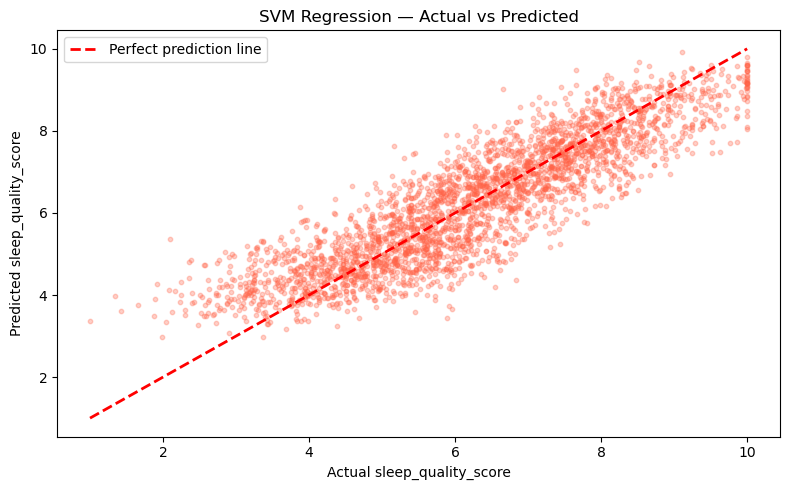

In [33]:
# best model predictions
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

# evaluate
svm_results = evaluate_regression(y_test, y_pred_svm, 'SVM Regression')
regression_results.append(svm_results)

# actual vs predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_svm, alpha=0.3, color='tomato', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual sleep_quality_score')
plt.ylabel('Predicted sleep_quality_score')
plt.title('SVM Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
cv_scores_svm = cross_val_score(best_svm, X_train_scaled, y_train,
                                 cv=5, scoring='r2', n_jobs=-1)

print("=== Cross Validation — SVM Regression ===")
print(f"CV R² scores : {cv_scores_svm.round(4)}")
print(f"Mean R²      : {cv_scores_svm.mean().round(4)}")
print(f"Std R²       : {cv_scores_svm.std().round(4)}")

=== Cross Validation — SVM Regression ===
CV R² scores : [0.777  0.7852 0.7735 0.7812 0.7769]
Mean R²      : 0.7788
Std R²       : 0.0041


## Model 4 — SVM Regression Results

### Observations:
SVM was trained with rbf kernel and tuned using GridSearchCV across
144 parameter combinations (720 total fits across 5 folds).

- **Best parameters: C=100, gamma=0.1, epsilon=0.5**
  - C=100 → model fits training data strictly with low tolerance for errors
  - gamma=0.1 → moderate influence radius per training point
  - epsilon=0.5 → wider tolerance tube around predictions
- **R² = 0.7778** → Highest R² achieved so far, outperforming all previous models.
  Model explains 77.78% of variance in sleep quality score.
- **MAE = 0.6397** → Lowest prediction error across all models.
  On average predictions are off by 0.64 points on a 1-10 scale.
- **RMSE = 0.8048** → Lowest RMSE across all models.

### Cross Validation:
- CV Mean R² = 0.7788 — slightly higher than test R² (0.7778),
  confirming model is not overfitting to test data.
- CV Std = 0.0041 — stable and consistent across all 5 folds.
- Gamma consistently found optimal at 0.1 across both small and large
  parameter grids — strong indicator this is the true optimal value.

### Why did SVM outperform linear models and Random Forest?
- rbf kernel captures mild non-linear patterns that linear models miss
  but in a more controlled way than Random Forest
- GridSearchCV with 720 fits found a well optimized parameter combination
- epsilon=0.5 tolerance tube reduces sensitivity to noisy predictions,
  particularly helpful given the synthetic nature of the dataset
- SVM's margin maximization approach generalizes better than
  Random Forest's averaging on this relatively small clean feature set

### Key takeaway:
SVM with rbf kernel and optimized hyperparameters is the best performing
model so far with R²=0.7778, MAE=0.6397, RMSE=0.8048.
The kernel based approach successfully captured mild non-linear patterns
that linear models missed while avoiding the overfitting tendency
observed in Random Forest.
New best model: SVM R²=0.7778

# Final Comparison:

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# compile all results into a dataframe
results_df = pd.DataFrame(regression_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== Final Model Comparison ===")
print(results_df)

=== Final Model Comparison ===
               Model     MAE     MSE    RMSE      R2
0     SVM Regression  0.6397  0.6478  0.8048  0.7778
1  Linear Regression  0.6522  0.6750  0.8216  0.7685
2   Ridge Regression  0.6522  0.6750  0.8216  0.7685
3      Random Forest  0.6667  0.6984  0.8357  0.7604


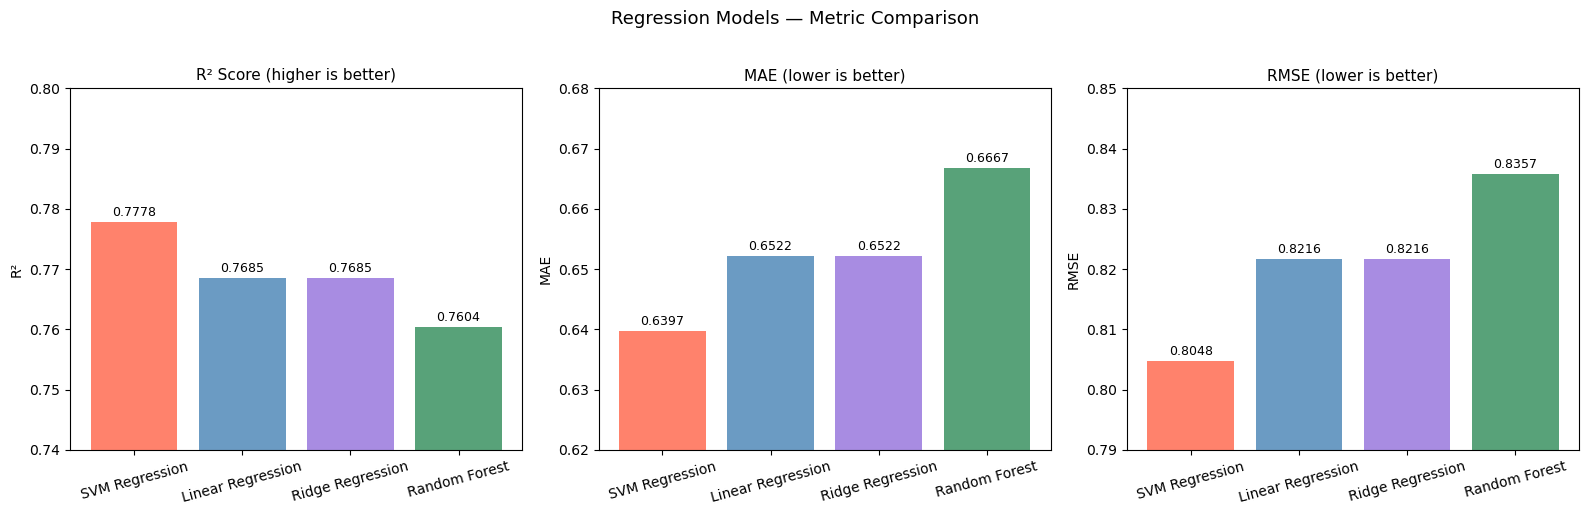

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results_df['Model']
colors = ['tomato', 'steelblue', 'mediumpurple', 'seagreen']

# R² plot
bars1 = axes[0].bar(models, results_df['R2'], color=colors, alpha=0.8)
axes[0].set_title('R² Score (higher is better)', fontsize=11)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.74, 0.80)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, results_df['R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.001,
                 str(val), ha='center', fontsize=9)

# MAE plot
bars2 = axes[1].bar(models, results_df['MAE'], color=colors, alpha=0.8)
axes[1].set_title('MAE (lower is better)', fontsize=11)
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0.62, 0.68)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results_df['MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 str(val), ha='center', fontsize=9)

# RMSE plot
bars3 = axes[2].bar(models, results_df['RMSE'], color=colors, alpha=0.8)
axes[2].set_title('RMSE (lower is better)', fontsize=11)
axes[2].set_ylabel('RMSE')
axes[2].set_ylim(0.79, 0.85)
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, results_df['RMSE']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 str(val), ha='center', fontsize=9)

plt.suptitle('Regression Models — Metric Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

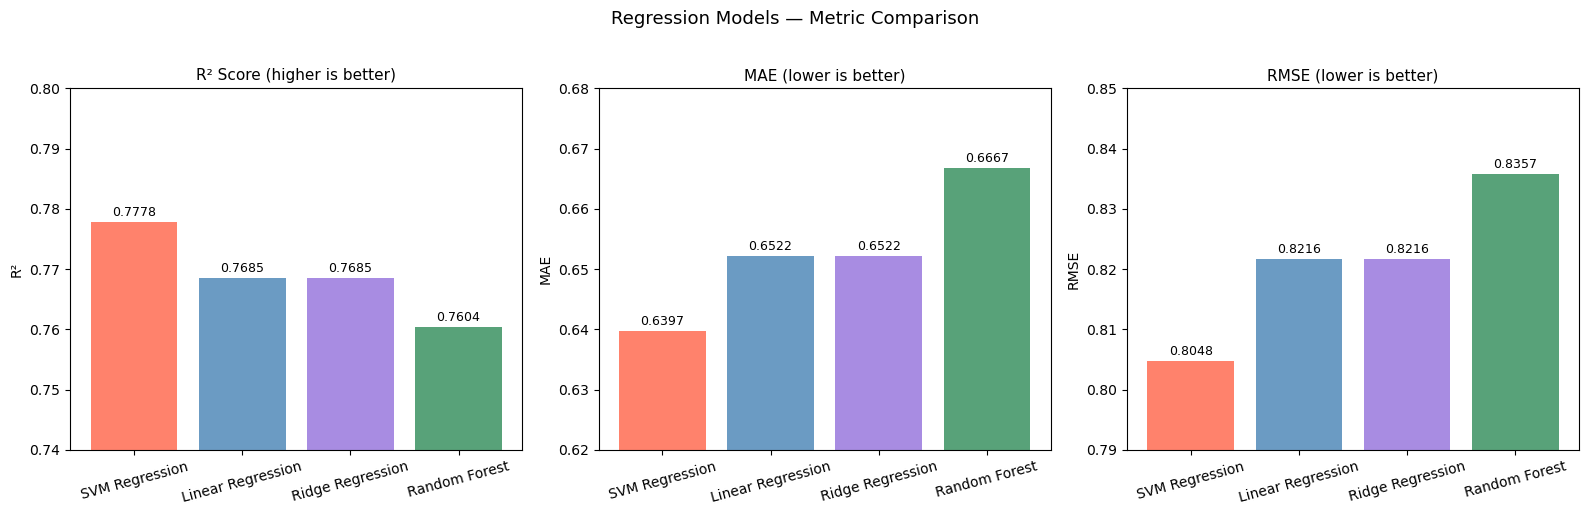

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = results_df['Model']
colors = ['tomato', 'steelblue', 'mediumpurple', 'seagreen']

# R² plot
bars1 = axes[0].bar(models, results_df['R2'], color=colors, alpha=0.8)
axes[0].set_title('R² Score (higher is better)', fontsize=11)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.74, 0.80)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, results_df['R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.001,
                 str(val), ha='center', fontsize=9)

# MAE plot
bars2 = axes[1].bar(models, results_df['MAE'], color=colors, alpha=0.8)
axes[1].set_title('MAE (lower is better)', fontsize=11)
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0.62, 0.68)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results_df['MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 str(val), ha='center', fontsize=9)

# RMSE plot
bars3 = axes[2].bar(models, results_df['RMSE'], color=colors, alpha=0.8)
axes[2].set_title('RMSE (lower is better)', fontsize=11)
axes[2].set_ylabel('RMSE')
axes[2].set_ylim(0.79, 0.85)
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, results_df['RMSE']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 str(val), ha='center', fontsize=9)

plt.suptitle('Regression Models — Metric Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/5w/40v6y__153s245ll58v9krdw0000gn/T/ipykernel_24489/1044348383.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(cv_data.values(), labels=cv_data.keys())


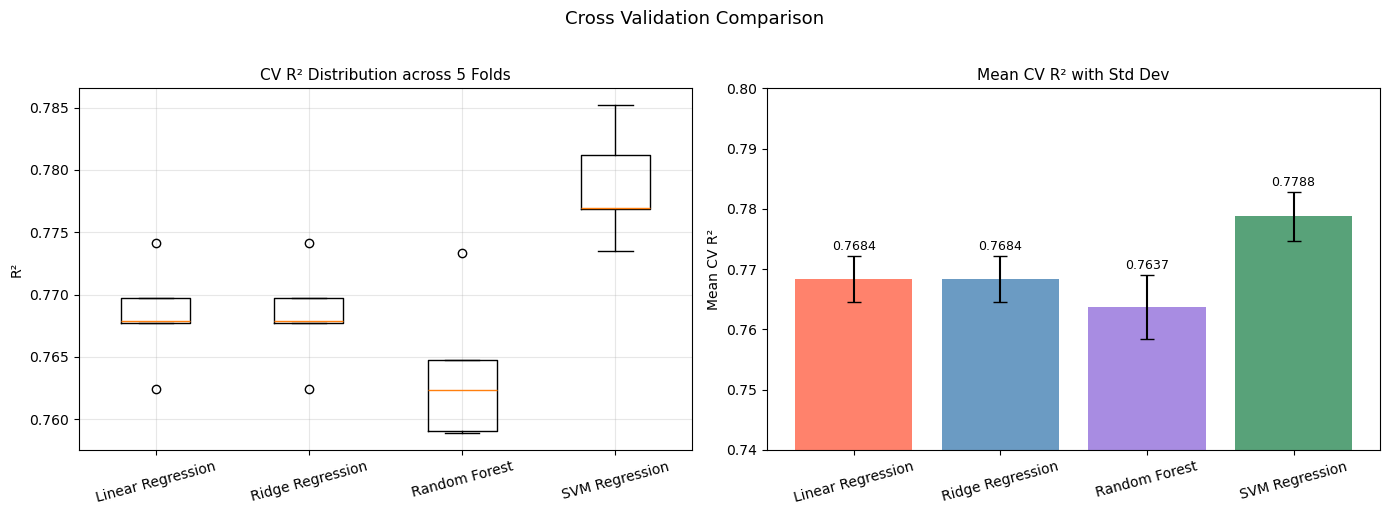

In [46]:
# cv scores for all models
cv_data = {
    'Linear Regression' : cv_scores_lr,
    'Ridge Regression'  : cv_scores_ridge,
    'Random Forest'     : cv_scores_rf,
    'SVM Regression'    : cv_scores_svm
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# box plot of cv scores
axes[0].boxplot(cv_data.values(), labels=cv_data.keys())
axes[0].set_title('CV R² Distribution across 5 Folds', fontsize=11)
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3)

# mean cv r² with error bars
means = [scores.mean() for scores in cv_data.values()]
stds  = [scores.std() for scores in cv_data.values()]

axes[1].bar(cv_data.keys(), means, 
            yerr=stds, 
            color=colors, 
            alpha=0.8,
            capsize=5)
axes[1].set_title('Mean CV R² with Std Dev', fontsize=11)
axes[1].set_ylabel('Mean CV R²')
axes[1].set_ylim(0.74, 0.80)
axes[1].tick_params(axis='x', rotation=15)
for i, (mean, std) in enumerate(zip(means, stds)):
    axes[1].text(i, mean + std + 0.001,
                 f'{mean:.4f}', ha='center', fontsize=9)

plt.suptitle('Cross Validation Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

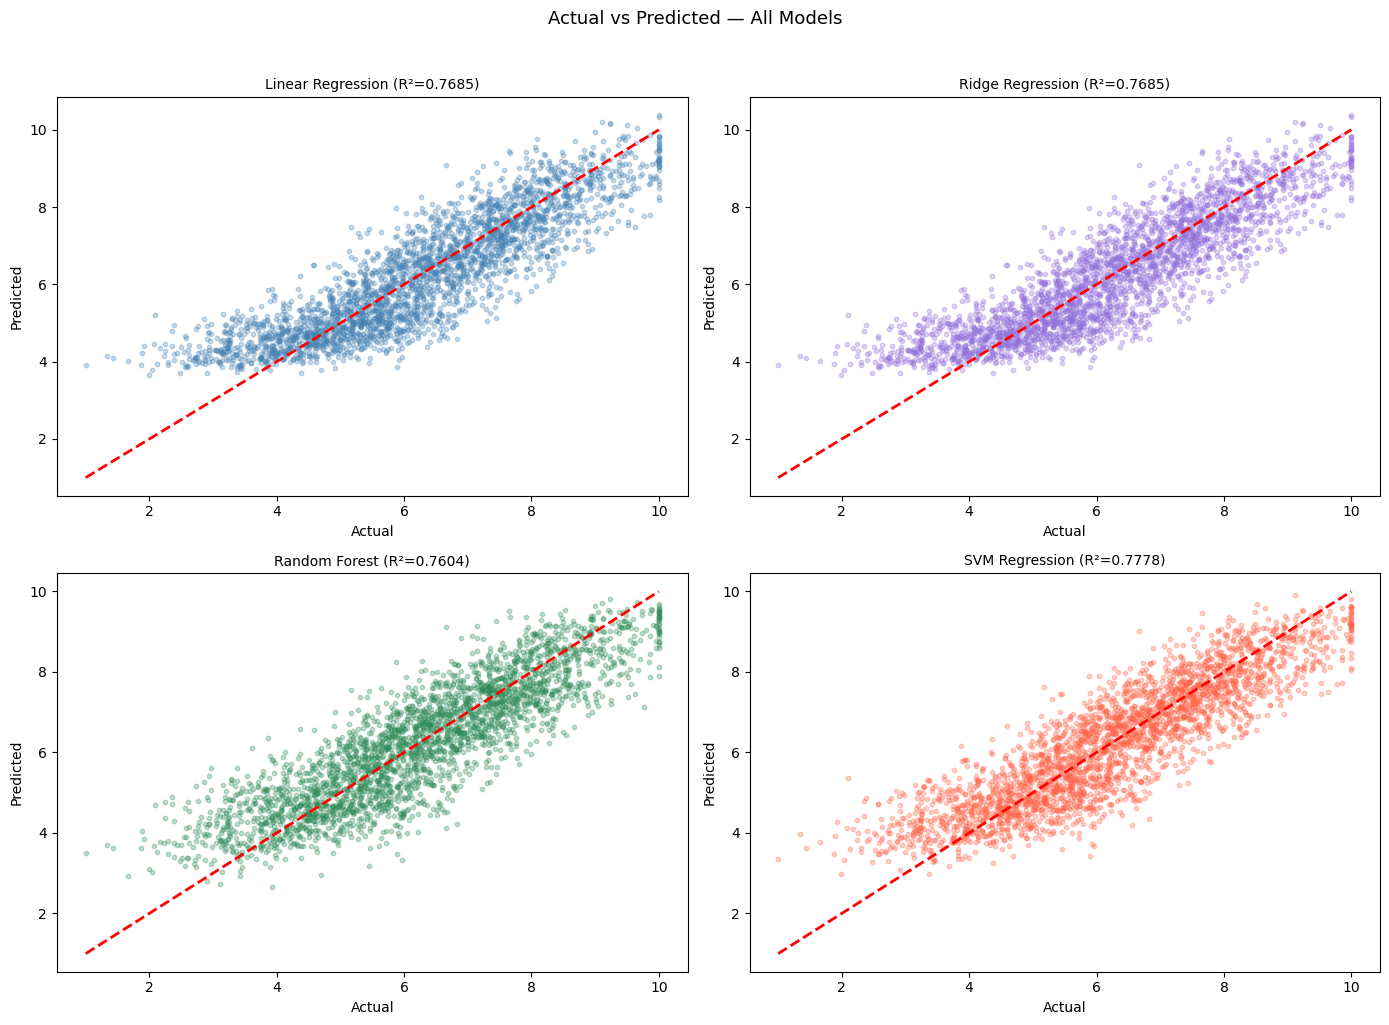

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

predictions = {
    'Linear Regression' : (y_pred_lr,    'steelblue'),
    'Ridge Regression'  : (y_pred_ridge, 'mediumpurple'),
    'Random Forest'     : (y_pred_rf,    'seagreen'),
    'SVM Regression'    : (y_pred_svm,   'tomato')
}

for i, (model_name, (y_pred, color)) in enumerate(predictions.items()):
    r2 = r2_score(y_test, y_pred)
    axes[i].scatter(y_test, y_pred, alpha=0.3, color=color, s=10)
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', linewidth=2)
    axes[i].set_title(f'{model_name} (R²={r2:.4f})', fontsize=10)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

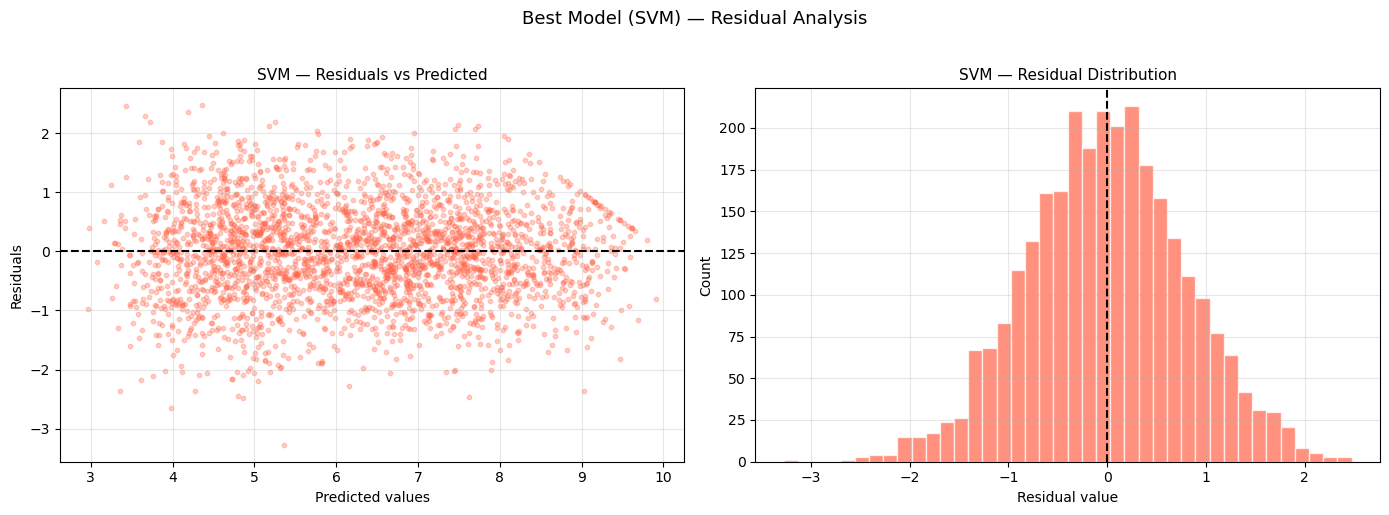

Mean residual : -0.0157
Std residual  : 0.8048


In [49]:
residuals = y_test - y_pred_svm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals vs predicted
axes[0].scatter(y_pred_svm, residuals, alpha=0.3, color='tomato', s=10)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('SVM — Residuals vs Predicted', fontsize=11)
axes[0].grid(True, alpha=0.3)

# residual distribution
axes[1].hist(residuals, bins=40, color='tomato', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')
axes[1].set_title('SVM — Residual Distribution', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Best Model (SVM) — Residual Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean residual : {residuals.mean().round(4)}")
print(f"Std residual  : {round(residuals.std(), 4)}")

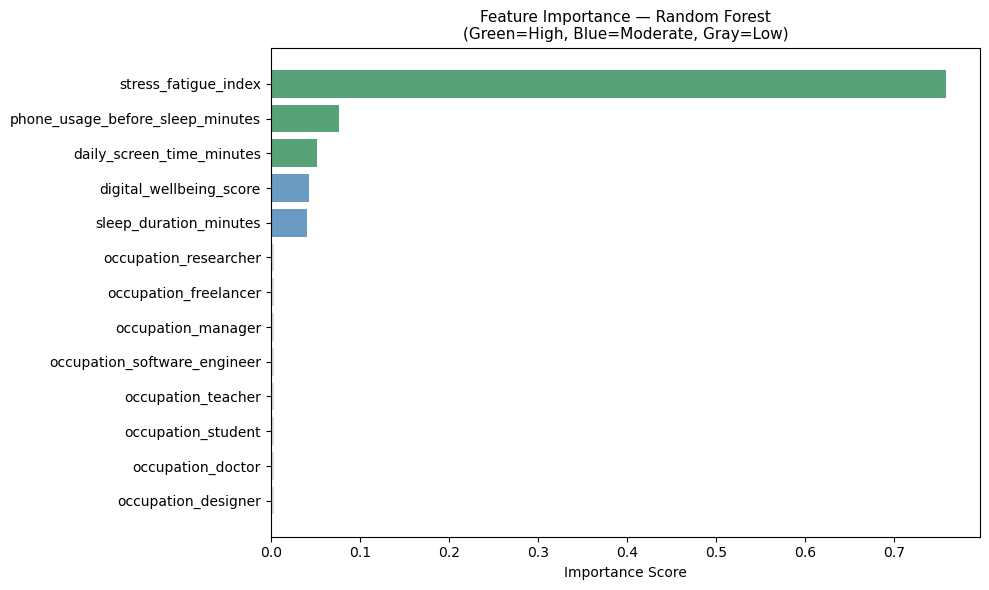

In [50]:
feature_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
colors_fi = ['seagreen' if imp > 0.05 else 
             'steelblue' if imp > 0.01 else 
             'lightgray' for imp in feature_importance['importance']]

plt.barh(feature_importance['feature'],
         feature_importance['importance'],
         color=colors_fi, alpha=0.8)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest\n(Green=High, Blue=Moderate, Gray=Low)',
          fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Final Regression Model Comparison — Summary

### Model Rankings:
| Rank | Model | R² | MAE | RMSE |
|------|-------|-----|-----|------|
| 1 | SVM Regression | 0.7778 | 0.6397 | 0.8048 |
| 2 | Linear Regression | 0.7685 | 0.6522 | 0.8216 |
| 2 | Ridge Regression | 0.7685 | 0.6522 | 0.8216 |
| 4 | Random Forest | 0.7604 | 0.6667 | 0.8357 |

### Key findings:
1. **SVM is the best model** — rbf kernel captured mild non-linear patterns
   that linear models missed, achieving R²=0.7778
2. **Linear and Ridge performed identically** — confirms clean feature set
   with no multicollinearity remaining after EDA
3. **Random Forest underperformed** — without leakage feature,
   relationships are predominantly linear, limiting tree based performance
4. **All models are stable** — CV Std between 0.0038-0.0053 across all models,
   no significant overfitting detected

### Data leakage finding:
sleep_efficiency_score was identified and removed as a leakage feature
since it contained the target variable in its formula.
Removing it dropped R² from 0.99 to ~0.77 — a more honest
and realistic performance for this type of prediction problem.

### Project conclusion for regression:
Smartphone usage patterns — particularly stress/fatigue levels,
phone usage before sleep and daily screen time — can predict
sleep quality with R²=0.7778 using SVM regression.
The dominant predictor is stress_fatigue_index (75.86% importance),
suggesting that the combined effect of stress and mental fatigue
is the strongest driver of sleep disruption.